# Percobaan Pengaruh Jumlah Layer LSTM

#### Import Dataset

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras import Sequential, Input
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Seeding

In [2]:
import random
import os

# Atur seed
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
tf.keras.utils.set_random_seed(seed_value)
tf.config.experimental.enable_op_determinism()
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'

#### Load Dataset

In [3]:
# Pemetaan label ke angka
label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

# Load Dataset NusaX-Sentiment
# Train dataset
df_train = pd.read_csv("../../datasets/indonesian/train.csv")
train_texts = df_train['text'].astype(str).tolist()
df_train['label'] = df_train['label'].map(label_mapping) # Pemetaan label ke angka
train_labels = df_train['label'].astype(int).tolist()

# Validation dataset
df_val = pd.read_csv("../../datasets/indonesian/valid.csv")
val_texts = df_val['text'].astype(str).tolist()
df_val['label'] = df_val['label'].map(label_mapping) # Pemetaan label ke angka
val_labels = df_val['label'].astype(int).tolist()

# Test dataset
df_test = pd.read_csv("../../datasets/indonesian/test.csv")
test_texts = df_test['text'].astype(str).tolist()
df_test['label'] = df_test['label'].map(label_mapping) # Pemetaan label ke angka
test_labels = df_test['label'].astype(int).tolist()

#### Preprocessing - Tokenization & Vectorization

In [4]:
# Split data
X_train, X_val, X_test, y_train, y_val, y_test = train_texts, val_texts, test_texts, train_labels, val_labels, test_labels

# TextVectorization (Tokenization)
MAX_TOKENS = 10000      # Jumlah maksimum kata unik
MAX_LEN = 100           # Panjang maksimum sequence

vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode='int',
    output_sequence_length=MAX_LEN,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    pad_to_max_tokens=True,
    ngrams=None,
)
vectorizer.adapt(X_train)

In [5]:
# 4. Dataset pipeline
def prepare_dataset(X, y):
    X_vec = vectorizer(tf.constant(X))
    return tf.data.Dataset.from_tensor_slices((X_vec, y)).batch(32).prefetch(tf.data.AUTOTUNE)

train_ds = prepare_dataset(X_train, y_train)
val_ds = prepare_dataset(X_val, y_val)
test_ds = prepare_dataset(X_test, y_test)

In [6]:
EMBED_DIM = 128
LSTM_UNITS = 64

## Model 1: 1 Layer LSTM

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.3959 - loss: 1.0890 - val_accuracy: 0.4200 - val_loss: 1.0329
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4708 - loss: 0.9813 - val_accuracy: 0.5500 - val_loss: 0.9102
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6469 - loss: 0.7907 - val_accuracy: 0.5900 - val_loss: 0.8532
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7547 - loss: 0.6053 - val_accuracy: 0.6400 - val_loss: 0.7689
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8698 - loss: 0.3844 - val_accuracy: 0.6800 - val_loss: 0.7553
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9297 - loss: 0.2344 - val_accuracy: 0.6900 - val_loss: 0.7269
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9824 - loss: 0.1114 - val_accuracy: 0.7200 - val_loss: 0.7305
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9942 - loss: 0.0554 - val_accuracy: 0.7700 - v

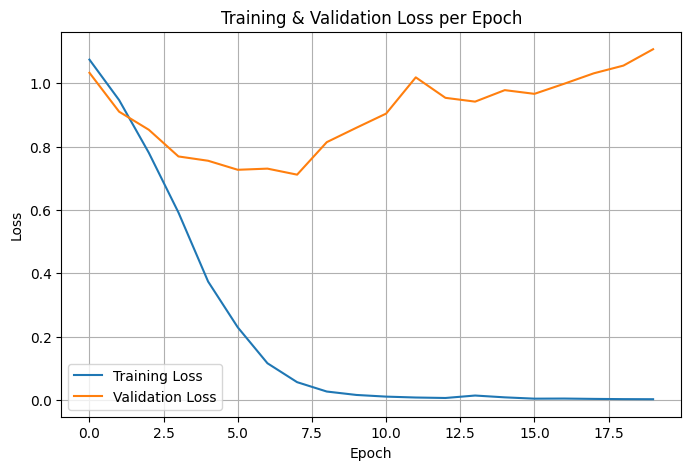

In [7]:
model1 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM),
    Bidirectional(LSTM(LSTM_UNITS)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


model1.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size=32
)

# Prediksi di test set
predictions = model1.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Hitung macro F1-Score
from sklearn.metrics import f1_score
macro_f1 = f1_score(test_labels, predicted_labels, average='macro')
print(f"Macro F1-Score: {macro_f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model 2: 2 Layer LSTM

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.3921 - loss: 1.0728 - val_accuracy: 0.4900 - val_loss: 0.9789
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5675 - loss: 0.8997 - val_accuracy: 0.5800 - val_loss: 0.9052
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.6858 - loss: 0.7250 - val_accuracy: 0.6300 - val_loss: 0.7885
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8323 - loss: 0.4524 - val_accuracy: 0.6300 - val_loss: 1.0061
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9465 - loss: 0.2167 - val_accuracy: 0.7100 - val_loss: 0.8681
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9742 - loss: 0.0954 - val_accuracy: 0.7200 - val_loss: 0.9463
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9969 - loss: 0.0425 - val_accuracy: 0.7500 - val_loss: 1.0222
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9906 - loss: 0.0499 - val_accuracy: 0.6700 - v

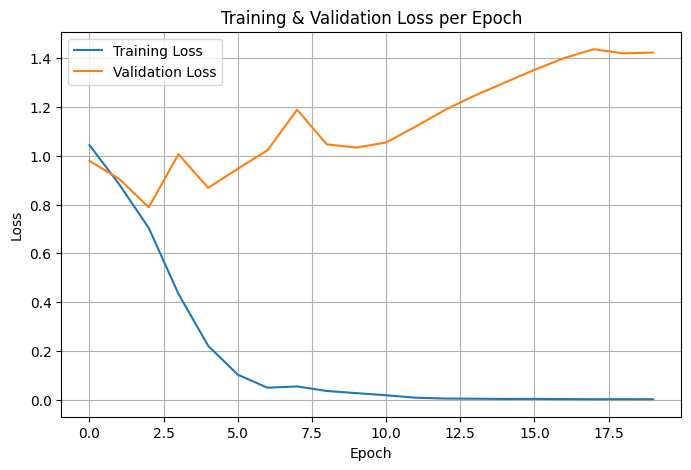

In [8]:
model2 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True)),
    Bidirectional(LSTM(LSTM_UNITS)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


model2.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size=32
)

# Prediksi di test set
predictions = model2.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Hitung macro F1-Score
from sklearn.metrics import f1_score
macro_f1 = f1_score(test_labels, predicted_labels, average='macro')
print(f"Macro F1-Score: {macro_f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Model 3: 3 Layer LSTM

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.4024 - loss: 1.0776 - val_accuracy: 0.5100 - val_loss: 0.9767
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5238 - loss: 0.9061 - val_accuracy: 0.5700 - val_loss: 0.9044
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.7130 - loss: 0.6749 - val_accuracy: 0.6200 - val_loss: 0.7666
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.8613 - loss: 0.3448 - val_accuracy: 0.6800 - val_loss: 0.8485
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9668 - loss: 0.1121 - val_accuracy: 0.7200 - val_loss: 0.9631
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9845 - loss: 0.0845 - val_accuracy: 0.7100 - val_loss: 1.0591
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.9886 - loss: 0.0561 - val_accuracy: 0.6900 - val_loss: 1.0050
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9970 - loss: 0.0247 - val_accuracy: 0.6900 - 

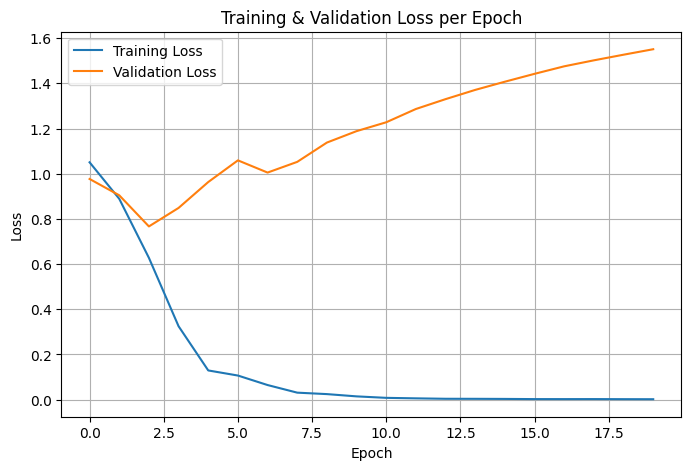

In [9]:
model3 = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True)),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True)),
    Bidirectional(LSTM(LSTM_UNITS)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


model3.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    batch_size=32
)

# Prediksi di test set
predictions = model3.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Hitung macro F1-Score
from sklearn.metrics import f1_score
macro_f1 = f1_score(test_labels, predicted_labels, average='macro')
print(f"Macro F1-Score: {macro_f1:.4f}")

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()